In [88]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import time
from itertools import combinations

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import KNNImputer
from sklearn.covariance import EllipticEnvelope
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import SGDOneClassSVM
from sklearn.kernel_approximation import Nystroem
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split

## Chargement des données

In [89]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()

,Patient,Hipp,P300,P600,LNC,N400,LRC,IQ,VCI,PRI,WMI,SPI,VBL,VSL,VBD,VSD,OB,ON
0,2 D,NI,-68.8,82.60,-54.1,NaN,NaN,96.0,98.0,100.0,91.0,94.0,105.0,123.0,101.0,115.0,98%,80/77
1,3 G,NI,-44.7,80.00,-46.9,0.0,4.69,122.0,116.0,124.0,120.0,105.0,105.0,103.0,104.0,103.0,NaN,NaN
2,4 D,NI,-108.1,96.40,-26.6,-50.7,-0.55,86.0,82.0,94.0,86.0,100.0,79.0,91.0,69.0,88.0,98%,62/70
3,6 D,NI,-35.3,0.00,0.0,23.7,-0.30,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69
4,6 G,NI,-38.7,42.14,0.0,NaN,NaN,67.0,71.0,86.0,68.0,64.0,102.0,85.0,104.0,85.0,88%,53/69


In [90]:
X = raw_df[['P300', 'P600', 'LNC', 'N400', 'LRC', 'OB', 'ON', 'Hipp']]
y = raw_df[['WMI']]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.33,
    random_state=42
)

## Encodage de la variable categorielle Hipp

On encode Hipp tout au debut, avant le nettoyage et l'imputation, pour que ces etapes
s'appliquent aussi aux colonnes generees (Hipp_NI, Hipp_ZE, Hipp_ZP, ...).

In [91]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

hipp_encoded = encoder.fit_transform(X_train[['Hipp']])

hipp_columns = encoder.get_feature_names_out(['Hipp'])

hipp_encoded_df = pd.DataFrame(
    hipp_encoded,
    columns=hipp_columns,
    index=X_train.index
)

X_train = pd.concat(
    [
        X_train.drop(columns='Hipp'),
        hipp_encoded_df
    ],
    axis=1
)

In [92]:
print(type(X))
print(type(X_train))
print(type(raw_df))
print(X_train)

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
     P300    P600    LNC   N400    LRC    OB     ON  Hipp_NI  Hipp_ZE  Hipp_ZP
4   -38.7   42.14    0.0    NaN    NaN   88%  53/69      1.0      0.0      0.0
48    0.0  157.90  -39.7  -31.9   0.00   NaN    NaN      0.0      1.0      0.0
36 -103.5  184.60  -62.4  -26.7   0.00   NaN    NaN      0.0      1.0      0.0
19 -293.4   50.60  -39.3  -27.8   6.40     1    NaN      0.0      0.0      1.0
55    0.0    0.00  -66.5  -20.2   0.00     1  57/78      0.0      1.0      0.0
58  -57.0  -36.30   32.8    NaN    NaN  0.93    NaN      0.0      1.0      0.0
56 -131.5  115.20 -170.2   30.0  -3.80   NaN    NaN      0.0      1.0      0.0
50  -47.7  165.10  -55.4    NaN    NaN   NaN    NaN      0.0      1.0      0.0
31    NaN     NaN    NaN    0.0   0.00  0.93    NaN      0.0      0.0      1.0
44 -165.8   86.20  -20.1    0.0   0.00  100%  68/79      0.0      1.0      0.0
62  -55.8   55.90  -32.3    NaN    NaN   NaN    Na

## Nettoyage des données

In [93]:
data_train = pd.concat([X_train, y_train], axis=1)
percent_missing = data_train.isnull().sum() * 100 / len(data_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         65.116279
OB         62.790698
LRC        30.232558
N400       30.232558
LNC         4.651163
P300        4.651163
P600        4.651163
WMI         4.651163
Hipp_NI     0.000000
Hipp_ZE     0.000000
Hipp_ZP     0.000000
dtype: float64

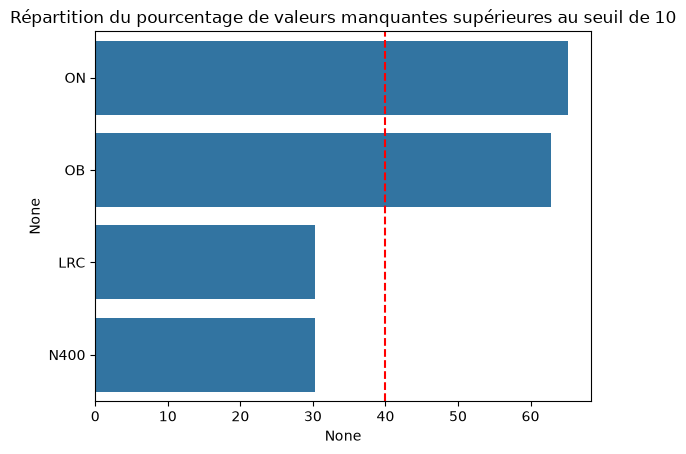

In [94]:
threshold_view = 10

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}")

threshold = 40
ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

In [95]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index
columns_to_drop

Index(['ON', 'OB'], dtype='str')

In [96]:
data_train.drop(columns=columns_to_drop, inplace=True, errors="ignore")
data_train

,P300,P600,LNC,N400,LRC,Hipp_NI,Hipp_ZE,Hipp_ZP,WMI
4,-38.7,42.14,0.0,NaN,NaN,1.0,0.0,0.0,68.0
48,0.0,157.90,-39.7,-31.9,0.00,0.0,1.0,0.0,97.0
36,-103.5,184.60,-62.4,-26.7,0.00,0.0,1.0,0.0,55.0
19,-293.4,50.60,-39.3,-27.8,6.40,0.0,0.0,1.0,94.0
55,0.0,0.00,-66.5,-20.2,0.00,0.0,1.0,0.0,109.0
58,-57.0,-36.30,32.8,NaN,NaN,0.0,1.0,0.0,94.0
56,-131.5,115.20,-170.2,30.0,-3.80,0.0,1.0,0.0,88.0
50,-47.7,165.10,-55.4,NaN,NaN,0.0,1.0,0.0,52.0
31,NaN,NaN,NaN,0.0,0.00,0.0,0.0,1.0,94.0
44,-165.8,86.20,-20.1,0.0,0.00,0.0,1.0,0.0,85.0


## Imputation des valeurs manquantes

In [97]:
numeric_features = data_train.select_dtypes(include=['float', 'int'])
numeric_features.shape

(43, 9)

In [98]:
imputation = KNNImputer(missing_values=np.nan)
numeric_features = numeric_features.loc[:, ~numeric_features.columns.duplicated()]
imputed = imputation.fit_transform(numeric_features)
imputed = pd.DataFrame(imputed, columns=numeric_features.columns, index=data_train.index)
imputed.shape

(43, 9)

In [99]:
data_train.loc[:, numeric_features.columns] = imputed
numeric_features.columns

Index(['P300', 'P600', 'LNC', 'N400', 'LRC', 'Hipp_NI', 'Hipp_ZE', 'Hipp_ZP',
       'WMI'],
      dtype='str')

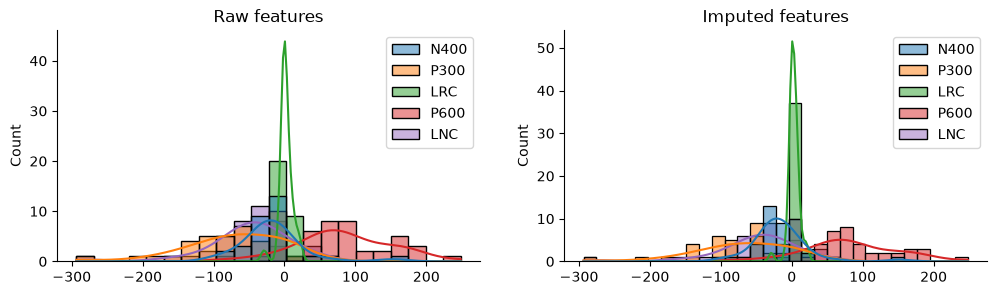

In [100]:
def compare_dist(features):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    ax = axes[0]
    sns.histplot(X_train.loc[:, features], kde=True, ax=ax)
    ax.set_title("Raw features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax = axes[1]
    sns.histplot(imputed.loc[:, features], kde=True, ax=ax)
    ax.set_title("Imputed features")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

compare_dist(["N400", "P300", "LRC", "P600", "LNC"])

## Outliers

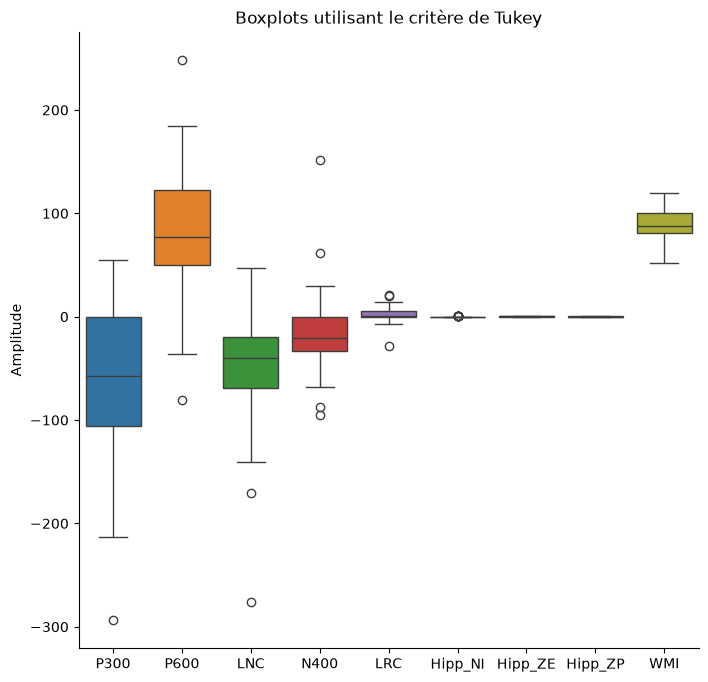

In [101]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.boxplot(data=data_train, ax=ax)
ax.set_ylabel("Amplitude")
ax.set_title("Boxplots utilisant le critère de Tukey")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

In [102]:
imputed

,P300,P600,LNC,N400,LRC,Hipp_NI,Hipp_ZE,Hipp_ZP,WMI
4,-38.70,42.14,0.00,-27.86,5.74,1.0,0.0,0.0,68.0
48,0.00,157.90,-39.70,-31.90,0.00,0.0,1.0,0.0,97.0
36,-103.50,184.60,-62.40,-26.70,0.00,0.0,1.0,0.0,55.0
19,-293.40,50.60,-39.30,-27.80,6.40,0.0,0.0,1.0,94.0
55,0.00,0.00,-66.50,-20.20,0.00,0.0,1.0,0.0,109.0
58,-57.00,-36.30,32.80,-10.32,6.62,0.0,1.0,0.0,94.0
56,-131.50,115.20,-170.20,30.00,-3.80,0.0,1.0,0.0,88.0
50,-47.70,165.10,-55.40,12.34,1.78,0.0,1.0,0.0,52.0
31,-51.12,77.46,-39.24,0.00,0.00,0.0,0.0,1.0,94.0
44,-165.80,86.20,-20.10,0.00,0.00,0.0,1.0,0.0,85.0


## Comparaison des méthodes de détection d'outliers

In [103]:
column_pairs = list(combinations(X_train.columns, 2))
outliers_fraction = 0.15

anomaly_algorithms = {
    "Robust covariance": lambda: EllipticEnvelope(contamination=outliers_fraction, random_state=42),
    "One-Class SVM": lambda: OneClassSVM(nu=outliers_fraction, kernel="rbf", gamma=0.1),
    "One-Class SVM (SGD)": lambda: make_pipeline(
        Nystroem(gamma=0.1, random_state=42, n_components=150),
        SGDOneClassSVM(nu=outliers_fraction, shuffle=True, fit_intercept=True,
                        random_state=42, tol=1e-6),
    ),
    "Isolation Forest": lambda: IsolationForest(contamination=outliers_fraction, random_state=42),
    "Local Outlier Factor": lambda: LocalOutlierFactor(n_neighbors=35, contamination=outliers_fraction),
}

agreement_scores = {name: [] for name in anomaly_algorithms}
fraction_detected = {name: [] for name in anomaly_algorithms}
timings = {name: [] for name in anomaly_algorithms}
failed_pairs = {name: [] for name in anomaly_algorithms}

for col_x, col_y in column_pairs:
    if col_x not in imputed.columns or col_y not in imputed.columns:
        continue
    
    X = imputed[[col_x, col_y]].to_numpy()

    if np.isnan(X).any():
        continue

    predictions = {}

    for name, make_algo in anomaly_algorithms.items():
        algo = make_algo()
        try:
            t0 = time.time()
            if name == "Local Outlier Factor":
                y_pred = algo.fit_predict(X)
            else:
                y_pred = algo.fit(X).predict(X)
            t1 = time.time()

            predictions[name] = y_pred
            timings[name].append(t1 - t0)
            fraction_detected[name].append(np.mean(y_pred == -1))
        except Exception:
            failed_pairs[name].append((col_x, col_y))
            predictions[name] = None

    valid_preds = {k: v for k, v in predictions.items() if v is not None}
    if len(valid_preds) < 2:
        continue

    stacked = np.stack(list(valid_preds.values()))
    consensus = np.sign(np.sum(stacked, axis=0))
    consensus[consensus == 0] = 1

    for name, y_pred in valid_preds.items():
        agreement = np.mean(y_pred == consensus)
        agreement_scores[name].append(agreement)

summary = []
for name in anomaly_algorithms:
    mean_agreement = np.mean(agreement_scores[name]) if agreement_scores[name] else np.nan
    mean_fraction = np.mean(fraction_detected[name]) if fraction_detected[name] else np.nan
    std_fraction = np.std(fraction_detected[name]) if fraction_detected[name] else np.nan
    mean_time = np.mean(timings[name]) if timings[name] else np.nan
    n_failed = len(failed_pairs[name])

    summary.append({
        "Méthode": name,
        "Accord moyen avec consensus": round(mean_agreement, 3),
        "Fraction outliers détectés (moy)": round(mean_fraction, 3),
        "Fraction outliers (écart-type)": round(std_fraction, 3),
        "Temps moyen (s)": round(mean_time, 4),
        "Paires échouées": n_failed,
    })

summary_df = pd.DataFrame(summary).sort_values(
    "Accord moyen avec consensus", ascending=False
).reset_index(drop=True)

summary_df

c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was set to n_samples, which results in inefficient evaluation of the full kernel.
  warnings.warn(
c:\Users\melan\DESU_DATA_2026\ProjetNR\.venv\Lib\site-packages\sklearn\kernel_approximation.py:1041: UserWarning: n_components > n_samples. This is not possible.
n_components was

,Méthode,Accord moyen avec consensus,Fraction outliers détectés (moy),Fraction outliers (écart-type),Temps moyen (s),Paires échouées
0,Robust covariance,0.956,0.145,0.050,0.0345,0
1,Local Outlier Factor,0.949,0.145,0.050,0.0036,0
2,Isolation Forest,0.944,0.145,0.050,0.1591,0
3,One-Class SVM (SGD),0.847,0.085,0.140,0.0073,0
4,One-Class SVM,0.550,0.465,0.147,0.0012,0


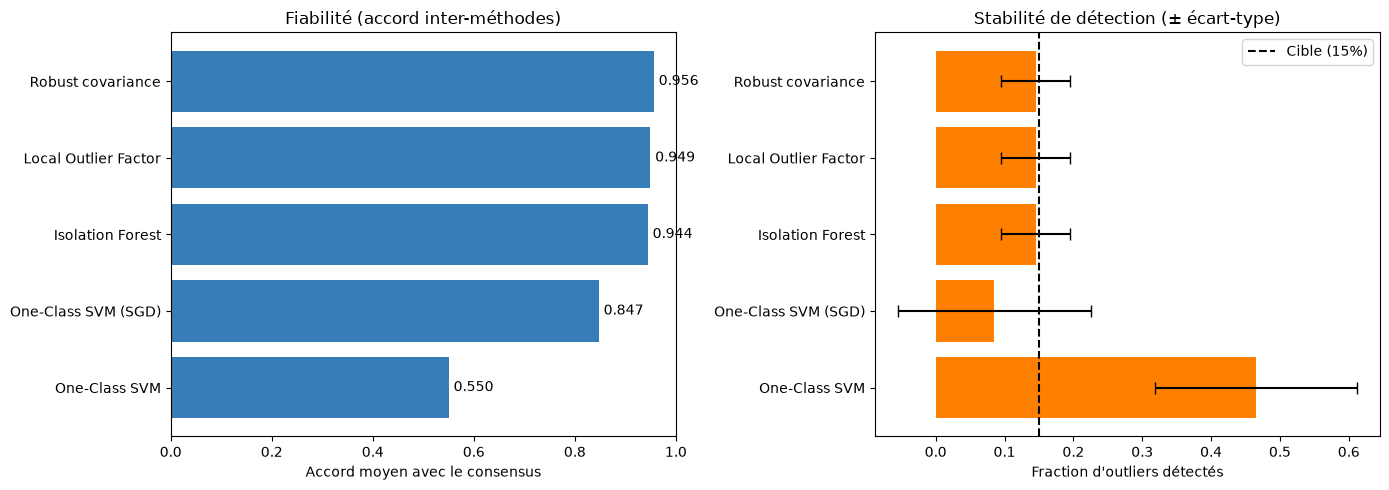

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(summary_df["Méthode"], summary_df["Accord moyen avec consensus"], color="#377eb8")
axes[0].set_xlabel("Accord moyen avec le consensus")
axes[0].set_xlim(0, 1)
axes[0].set_title("Fiabilité (accord inter-méthodes)")
axes[0].invert_yaxis()
for i, v in enumerate(summary_df["Accord moyen avec consensus"]):
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center")

axes[1].barh(
    summary_df["Méthode"],
    summary_df["Fraction outliers détectés (moy)"],
    xerr=summary_df["Fraction outliers (écart-type)"],
    color="#ff7f00",
    capsize=4
)
axes[1].axvline(outliers_fraction, color="black", linestyle="--", label="Cible (15%)")
axes[1].set_xlabel("Fraction d'outliers détectés")
axes[1].set_title("Stabilité de détection (± écart-type)")
axes[1].invert_yaxis()
axes[1].legend()

plt.tight_layout()
plt.show()

**Conclusion : on retient l'Isolation Forest** pour la suite de l'analyse.

### Choix de contamination pour l'Isolation Forest

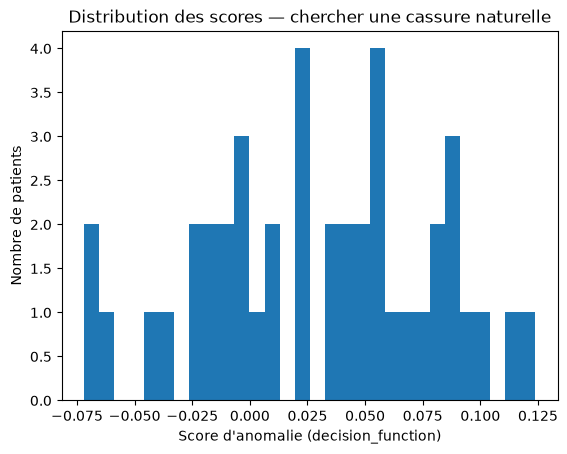

[-0.07188915 -0.06835251 -0.06452399 -0.04041408 -0.03753251 -0.0211079
 -0.02092799 -0.01844761 -0.0140585  -0.01288298 -0.00787437 -0.00166498
 -0.00145505 -0.00120465  0.00043806]


In [105]:
columns = imputed.columns.drop('WMI')
X = imputed[columns].to_numpy()

clf = IsolationForest(random_state=42, contamination="auto")
clf.fit(X)
scores = clf.decision_function(X)

plt.hist(scores, bins=30)
plt.xlabel("Score d'anomalie (decision_function)")
plt.ylabel("Nombre de patients")
plt.title("Distribution des scores — chercher une cassure naturelle")
plt.show()

print(np.sort(scores)[:15])

In [106]:
threshold = -0.02
n_outliers_visual = np.sum(scores < threshold)
contamination_estimated = n_outliers_visual / len(scores)

print(f"Nombre d'outliers estimé visuellement : {n_outliers_visual}")
print(f"Contamination estimée : {contamination_estimated:.3f}")

Nombre d'outliers estimé visuellement : 7
Contamination estimée : 0.163


## Figure finale : Isolation Forest sur toutes les paires de colonnes

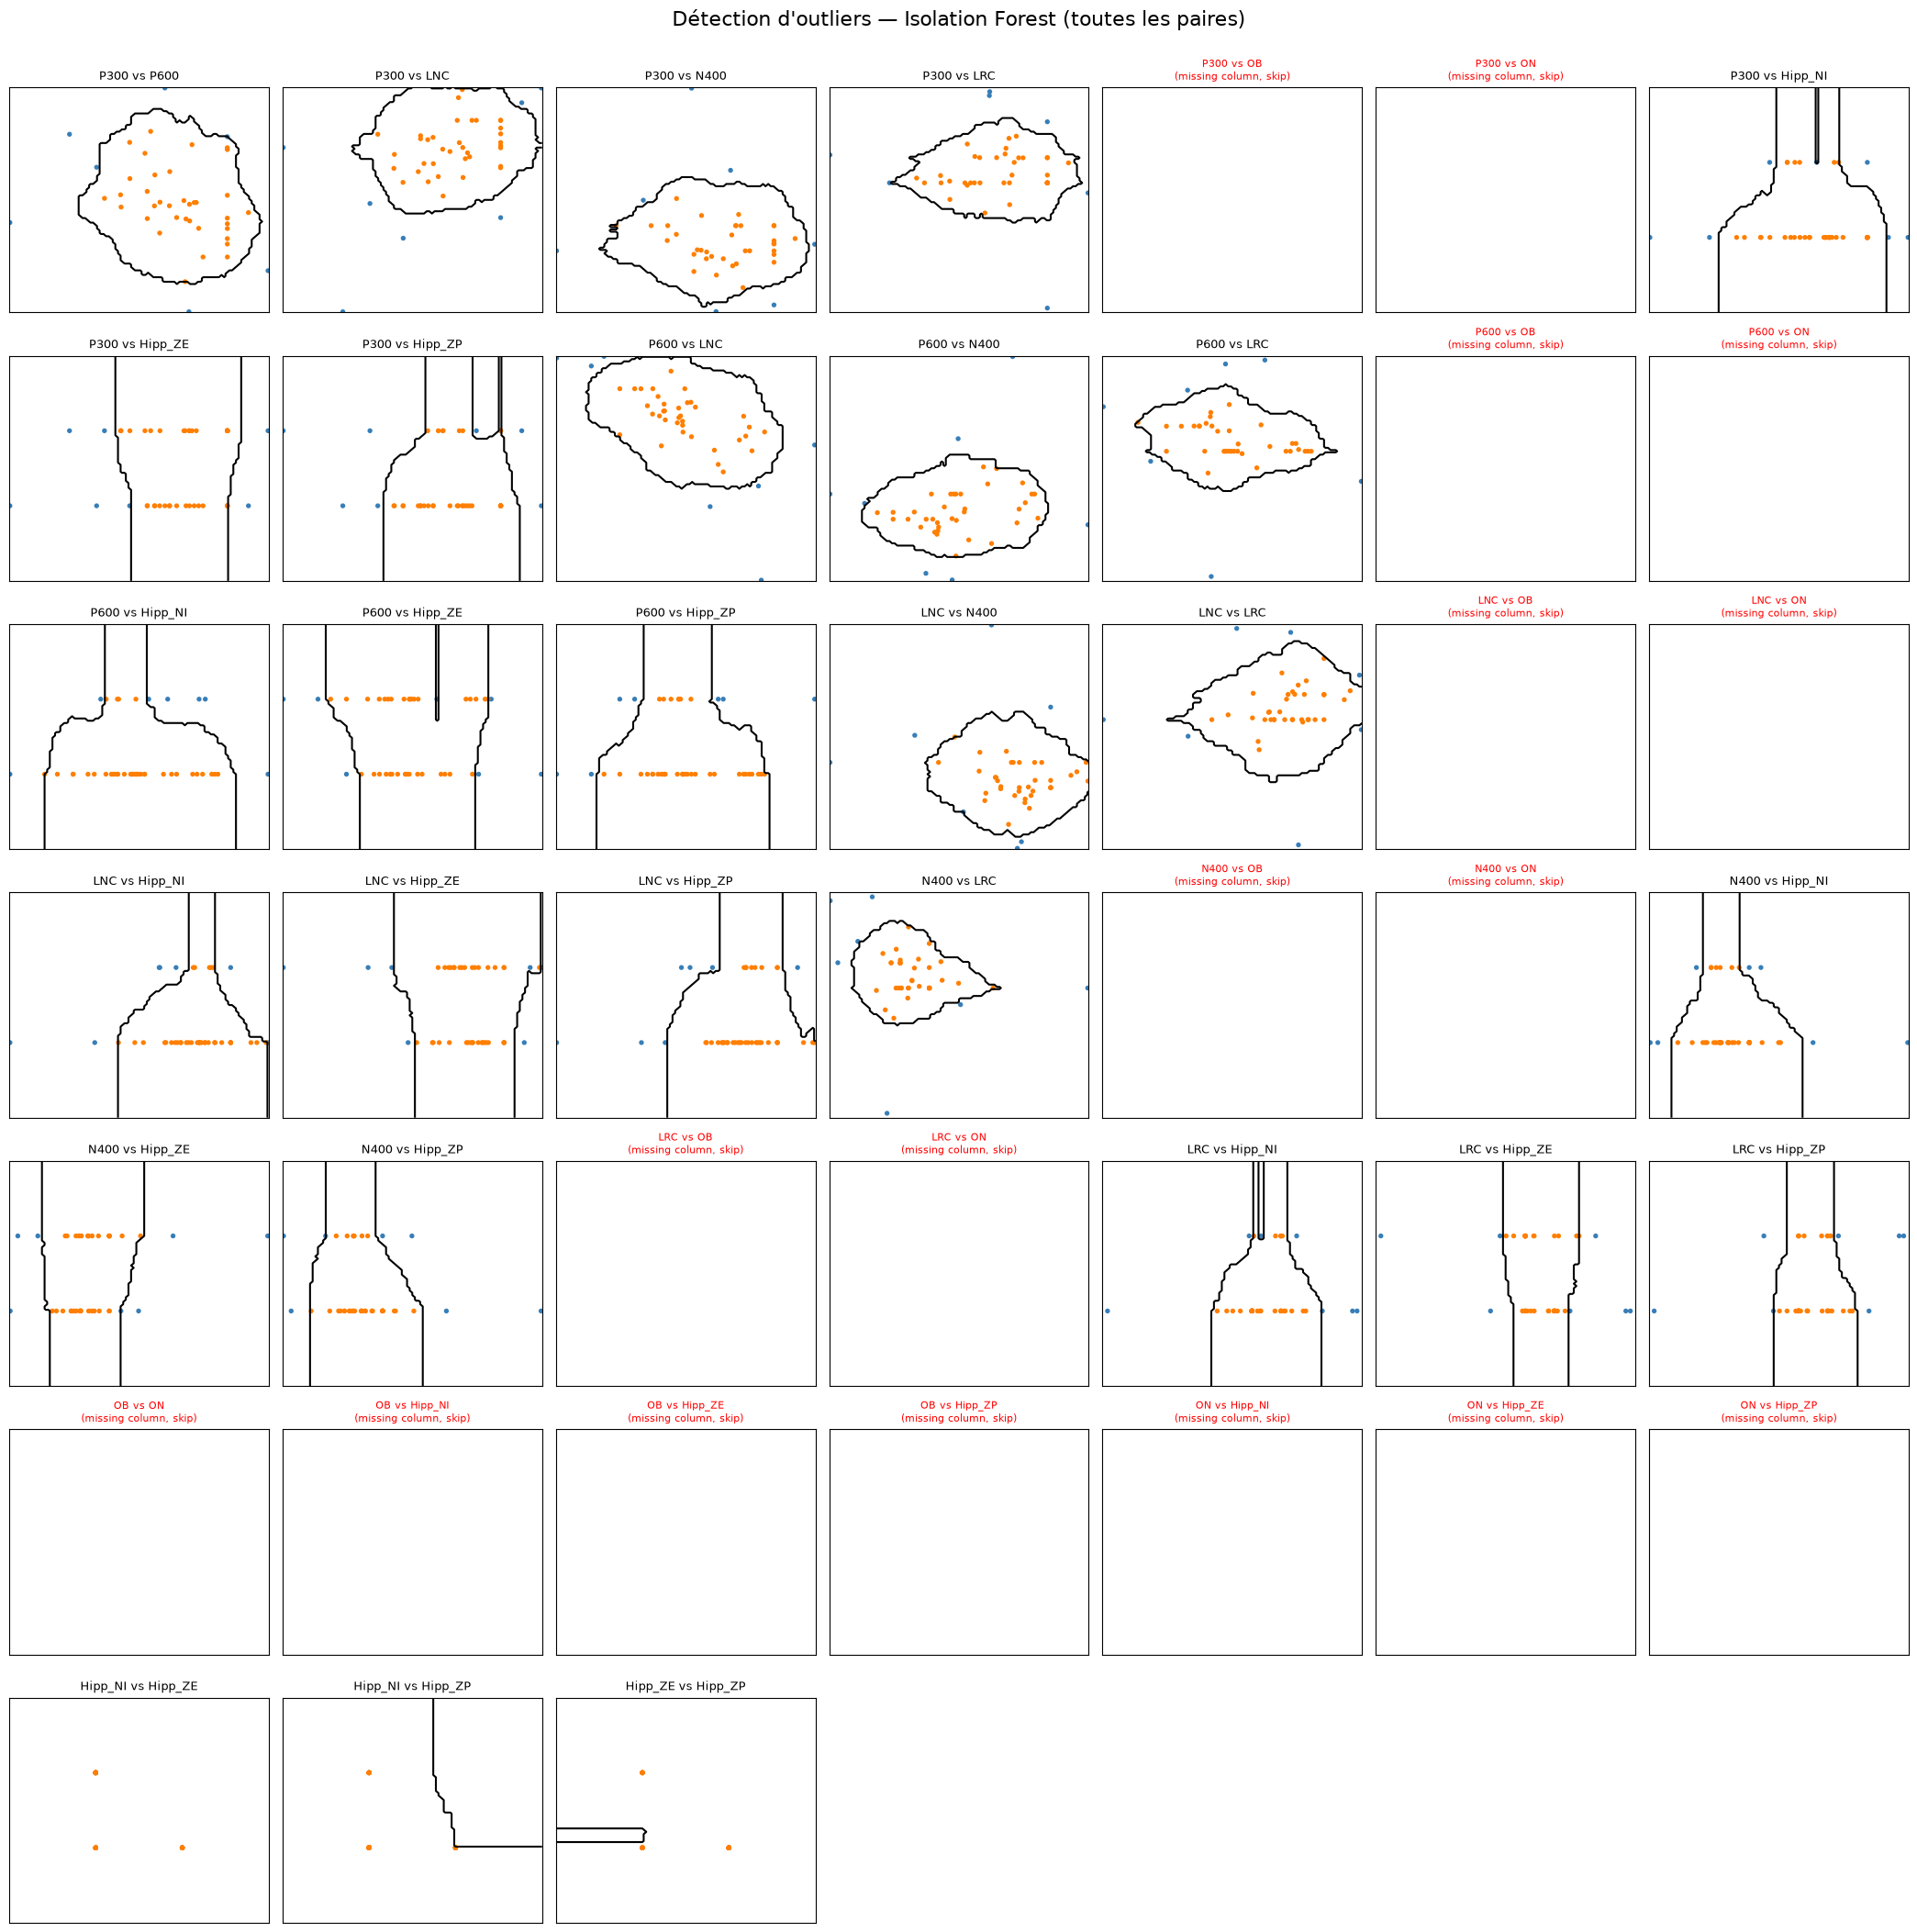

In [107]:
n_pairs = len(column_pairs)
n_cols = int(np.ceil(np.sqrt(n_pairs)))
n_rows = int(np.ceil(n_pairs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
axes = axes.flatten()

colors = np.array(["#377eb8", "#ff7f00"])

for i, (col_x, col_y) in enumerate(column_pairs):
    ax = axes[i]

    if col_x not in imputed.columns or col_y not in imputed.columns:
        ax.set_title(f"{col_x} vs {col_y}\n(missing column, skip)", fontsize=8, color="red")
        ax.set_xticks(())
        ax.set_yticks(())
        continue

    X_pair = imputed[[col_x, col_y]].to_numpy()

    if np.isnan(X_pair).any():
        ax.set_title(f"{col_x} vs {col_y}\n(NaN, skip)", fontsize=8, color="red")
        ax.set_xticks(())
        ax.set_yticks(())
        continue

    clf = IsolationForest(contamination=contamination_estimated, random_state=42)
    y_pred = clf.fit_predict(X_pair)

    x_min, x_max = X_pair[:, 0].min() - 1, X_pair[:, 0].max() + 1
    y_min, y_max = X_pair[:, 1].min() - 1, X_pair[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contour(xx, yy, Z, levels=[0], linewidths=1.5, colors="black")
    ax.scatter(X_pair[:, 0], X_pair[:, 1], s=8, color=colors[(y_pred + 1) // 2])

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"{col_x} vs {col_y}", fontsize=9)
    ax.set_xticks(())
    ax.set_yticks(())

for j in range(n_pairs, len(axes)):
    axes[j].axis("off")

fig.suptitle("Détection d'outliers — Isolation Forest (toutes les paires)", fontsize=16, y=1.0)
plt.tight_layout()
plt.savefig("isolation_forest_all_pairs.png", dpi=150, bbox_inches="tight")
plt.show()

## Test

In [108]:
X_train_imputed = imputed[[col for col in imputed.columns if col != 'WMI']]
X_train_imputed

,P300,P600,LNC,N400,LRC,Hipp_NI,Hipp_ZE,Hipp_ZP
4,-38.70,42.14,0.00,-27.86,5.74,1.0,0.0,0.0
48,0.00,157.90,-39.70,-31.90,0.00,0.0,1.0,0.0
36,-103.50,184.60,-62.40,-26.70,0.00,0.0,1.0,0.0
19,-293.40,50.60,-39.30,-27.80,6.40,0.0,0.0,1.0
55,0.00,0.00,-66.50,-20.20,0.00,0.0,1.0,0.0
58,-57.00,-36.30,32.80,-10.32,6.62,0.0,1.0,0.0
56,-131.50,115.20,-170.20,30.00,-3.80,0.0,1.0,0.0
50,-47.70,165.10,-55.40,12.34,1.78,0.0,1.0,0.0
31,-51.12,77.46,-39.24,0.00,0.00,0.0,0.0,1.0
44,-165.80,86.20,-20.10,0.00,0.00,0.0,1.0,0.0


In [109]:
y_train_imputed = imputed['WMI']

In [135]:
from sklearn.linear_model import Ridge
import pandas as pd

# ==========================
# 1) Préparer X_test
# ==========================

# Encoder Hipp avec le même encodeur que le train
if 'Hipp' in X_test.columns:
    
    hipp_encoded_test = encoder.transform(X_test[['Hipp']])

    hipp_columns = encoder.get_feature_names_out(['Hipp'])

    hipp_encoded_test_df = pd.DataFrame(
        hipp_encoded_test,
        columns=hipp_columns,
        index=X_test.index
    )

    # Remplacer Hipp par ses colonnes encodées
    X_test = pd.concat(
        [
            X_test.drop(columns=['Hipp'], errors='ignore'),
            hipp_encoded_test_df
        ],
        axis=1
    )


# Supprimer d'éventuelles anciennes colonnes catégorielles
X_test = X_test.drop(
    columns=['OB', 'ON'],
    errors='ignore'
)


# Réordonner les colonnes comme le train
X_test = X_test[X_train_imputed.columns]


# ==========================
# 2) Imputation de X_test
# ==========================

# Ajouter WMI si nécessaire pour respecter les colonnes vues au fit de l'imputer
X_test_for_imputation = X_test.copy()

if "WMI" not in X_test_for_imputation.columns:
    X_test_for_imputation["WMI"] = y_test.squeeze()

# Imputation avec les mêmes features qu'au fit
X_test_imputed = pd.DataFrame(
    imputation.transform(X_test_for_imputation),
    columns=X_test_for_imputation.columns,
    index=X_test_for_imputation.index
)

# Garder uniquement les variables d'entrée du modèle
X_test_imputed = X_test_imputed[X_train_imputed.columns]


In [141]:
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.cross_decomposition import PLSRegression
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)


# ==========================
# Modèles
# ==========================

models = {

    "Linear Regression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "Lasso": Lasso(
        alpha=0.1,
        max_iter=10000
    ),

    "Elastic Net": ElasticNet(
        alpha=0.1,
        l1_ratio=0.5,
        max_iter=10000
    ),

    "PLS Regression": PLSRegression(
        n_components=2
    ),

    "SVR": SVR(
        kernel="rbf",
        C=1,
        epsilon=0.1
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


# ==========================
# Validation croisée
# ==========================

cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)


results = []


for name, model in models.items():

    print("Evaluation :", name)

    pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            model
        )
    ])


    scores = cross_validate(
        pipeline,
        X_test_imputed,
        np.ravel(y_test),
        cv=cv,
        scoring={
            "R2": "r2",
            "RMSE": "neg_root_mean_squared_error",
            "MAE": "neg_mean_absolute_error"
        },
        return_train_score=False
    )


    results.append(
        {
            "Model": name,

            "R2_mean": np.mean(
                scores["test_R2"]
            ),

            "R2_std": np.std(
                scores["test_R2"]
            ),

        }
    )


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "R2_mean",
        ascending=False
    )
)


results_df

Evaluation : Linear Regression
Evaluation : Ridge
Evaluation : Lasso
Evaluation : Elastic Net
Evaluation : PLS Regression
Evaluation : SVR
Evaluation : Random Forest
Evaluation : Gradient Boosting


,Model,R2_mean,R2_std
6,Random Forest,-0.288097,0.778303
5,SVR,-0.452662,0.660101
7,Gradient Boosting,-0.662246,1.096871
4,PLS Regression,-1.060091,1.706107
3,Elastic Net,-1.173363,1.655124
1,Ridge,-1.177325,1.666636
2,Lasso,-1.388075,2.010960
0,Linear Regression,-1.475046,2.179781


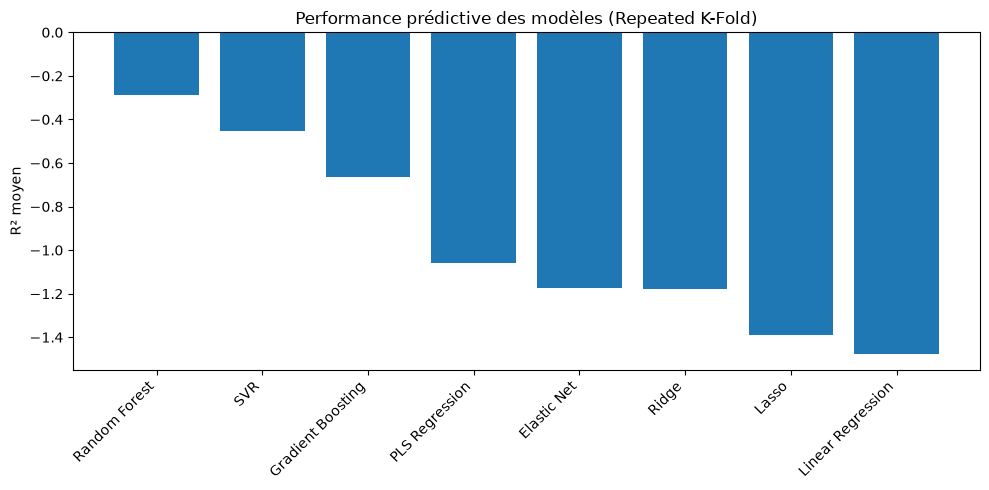

In [137]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["R2_mean"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("R² moyen")
plt.title("Performance prédictive des modèles (Repeated K-Fold)")

plt.tight_layout()
plt.show()

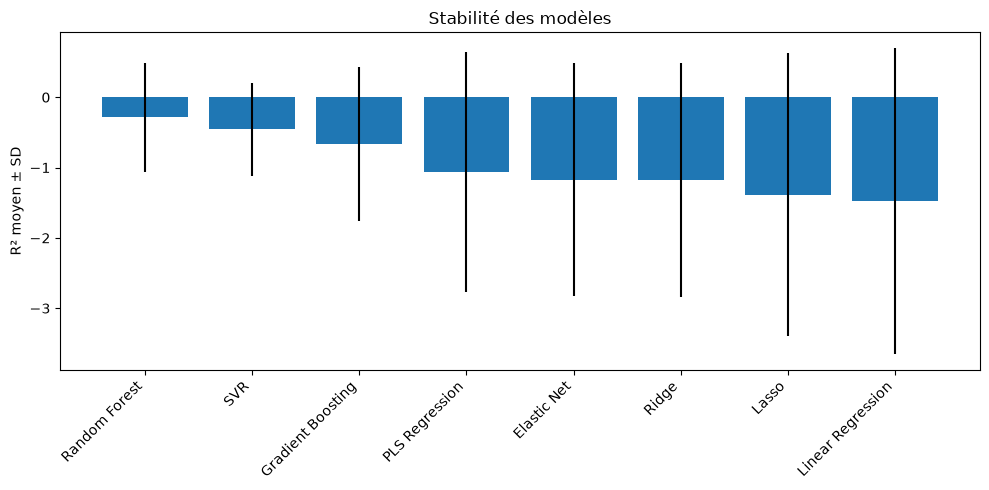

In [138]:
plt.figure(figsize=(10,5))

plt.bar(
    results_df["Model"],
    results_df["R2_mean"],
    yerr=results_df["R2_std"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel("R² moyen ± SD")
plt.title("Stabilité des modèles")

plt.tight_layout()
plt.show()

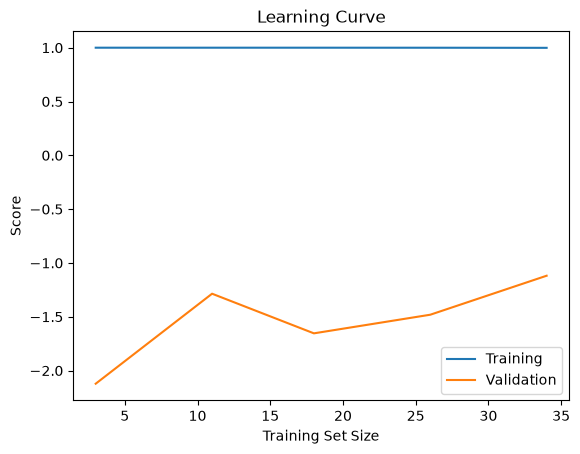

In [139]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_imputed,
    np.ravel(y_train_imputed),
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.plot(train_sizes, np.mean(train_scores, axis=1), label="Training")
plt.plot(train_sizes, np.mean(test_scores, axis=1), label="Validation")
plt.xlabel("Training Set Size")
plt.ylabel("Score")
plt.title("Learning Curve")
plt.legend()
plt.show()